# **Bài thực hành 5. Xác định mối quan hệ giữa các biến**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **5.1. Kiểm tra mối quan hệ giữa các thuộc tính và biến phản hồi**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/credit_card_clean_3.csv')

print("Kích thước bộ dữ liệu:", df.shape)
print("Thông tin bộ dữ liệu: ")
df.info()

Kích thước bộ dữ liệu: (26664, 30)
Thông tin bộ dữ liệu: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26664 entries, 0 to 26663
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          26664 non-null  object
 1   LIMIT_BAL                   26664 non-null  int64 
 2   SEX                         26664 non-null  int64 
 3   EDUCATION                   26664 non-null  int64 
 4   MARRIAGE                    26664 non-null  int64 
 5   AGE                         26664 non-null  int64 
 6   PAY_1                       26664 non-null  int64 
 7   PAY_2                       26664 non-null  int64 
 8   PAY_3                       26664 non-null  int64 
 9   PAY_4                       26664 non-null  int64 
 10  PAY_5                       26664 non-null  int64 
 11  PAY_6                       26664 non-null  int64 
 12  BILL_AMT1                   26664 non-null  

In [5]:
attrs = df.columns.tolist()

attrs_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'EDUCATION_CAT',
                   'graduate school', 'high school', 'none', 'others', 'university']
attrs = [att for att in attrs if att not in attrs_to_remove]

print("Các thuộc tính được giữ lại để phân tích:")
print(attrs)

Các thuộc tính được giữ lại để phân tích:
['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


Một phần của ma trận tương quan:


,LIMIT_BAL,EDUCATION,MARRIAGE,AGE,PAY_1
LIMIT_BAL,1.000000,-0.232688,-0.111873,0.149157,-0.273396
EDUCATION,-0.232688,1.000000,-0.137097,0.179035,0.112653
MARRIAGE,-0.111873,-0.137097,1.000000,-0.412828,0.019759
AGE,0.149157,0.179035,-0.412828,1.000000,-0.044277
PAY_1,-0.273396,0.112653,0.019759,-0.044277,1.000000


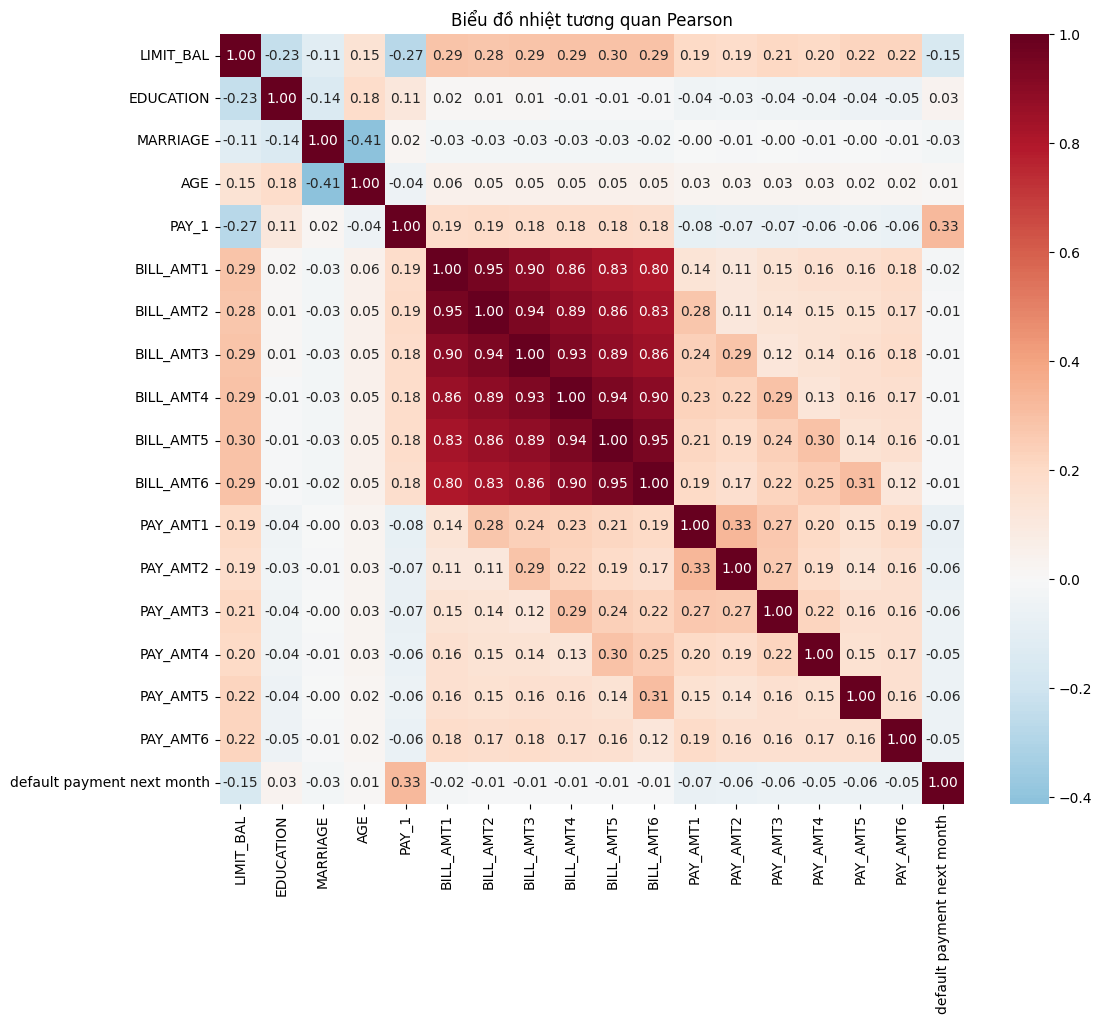

In [8]:
corr = df[attrs].corr()

print("Một phần của ma trận tương quan:")
display(corr.iloc[0:5, 0:5])

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            annot=True,
            fmt=".2f",
            center=0,
            cmap='RdBu_r')
plt.title('Biểu đồ nhiệt tương quan Pearson')
plt.show()

## **5.2. ANOVA F-test**

In [9]:
from sklearn.feature_selection import f_classif

X = df[attrs].iloc[:,:-1].values
y = df[attrs].iloc[:,-1].values

print(f"Kích thước X: {X.shape}, y: {y.shape}")

[f_stat, p_value] = f_classif(X, y)

f_test_df = pd.DataFrame({'Thuộc tính': attrs[:-1], 'F value': f_stat, 'p value': p_value})
f_test_df.sort_values('p value', inplace=True)

display(f_test_df)

Kích thước X: (26664, 17), y: (26664,)


,Thuộc tính,F value,p value
4,PAY_1,3156.672300,0.000000e+00
0,LIMIT_BAL,651.324071,5.838366e-142
11,PAY_AMT1,140.612679,2.358354e-32
12,PAY_AMT2,101.408321,8.256124e-24
13,PAY_AMT3,90.023873,2.542641e-21
15,PAY_AMT5,85.843295,2.090120e-20
16,PAY_AMT6,80.420784,3.219565e-19
14,PAY_AMT4,79.640021,4.774112e-19
1,EDUCATION,32.637768,1.122175e-08
2,MARRIAGE,18.078027,2.127555e-05


Kết quả thể hiện điều gì? Giá trị F càng lớn cho thấy sự khác biệt về giá trị trung bình của thuộc tính đó giữa nhóm "trả nợ đúng hạn" và "nợ xấu" là rất lớn. Giá trị p-value < 0.05 khẳng định mối liên hệ này có ý nghĩa thống kê.

Sự tương đồng: Kết quả ANOVA tương đồng với Pearson. Ví dụ, `PAY_1` thường có giá trị F cao nhất, cho thấy đây là biến quan trọng nhất để phân loại khách hàng.

## **5.3. Lựa chọn thuộc tính đơn biến với ANOVA**

In [10]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(f_classif, percentile=20)
selector.fit(X, y)

best_lst = selector.get_support()
attrs_exp = attrs[:-1]
selected_attrs = [attrs_exp[i] for i in range(len(attrs_exp)) if best_lst[i]]

print("Các thuộc tính nằm trong top 20% tốt nhất:")
print(selected_attrs)

Các thuộc tính nằm trong top 20% tốt nhất:
['LIMIT_BAL', 'PAY_1', 'PAY_AMT1', 'PAY_AMT2']


## **5.4. Bài tập: Chọn các biến giải thích theo k-top**

In [11]:
from sklearn.feature_selection import SelectKBest

selector_k = SelectKBest(f_classif, k=5)
selector_k.fit(X, y)

best_k_lst = selector_k.get_support()
selected_attrs_k = [attrs_exp[i] for i in range(len(attrs_exp)) if best_k_lst[i]]

print("5 thuộc tính quan trọng nhất được chọn bằng SelectKBest là:")
print(selected_attrs_k)

5 thuộc tính quan trọng nhất được chọn bằng SelectKBest là:
['LIMIT_BAL', 'PAY_1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']


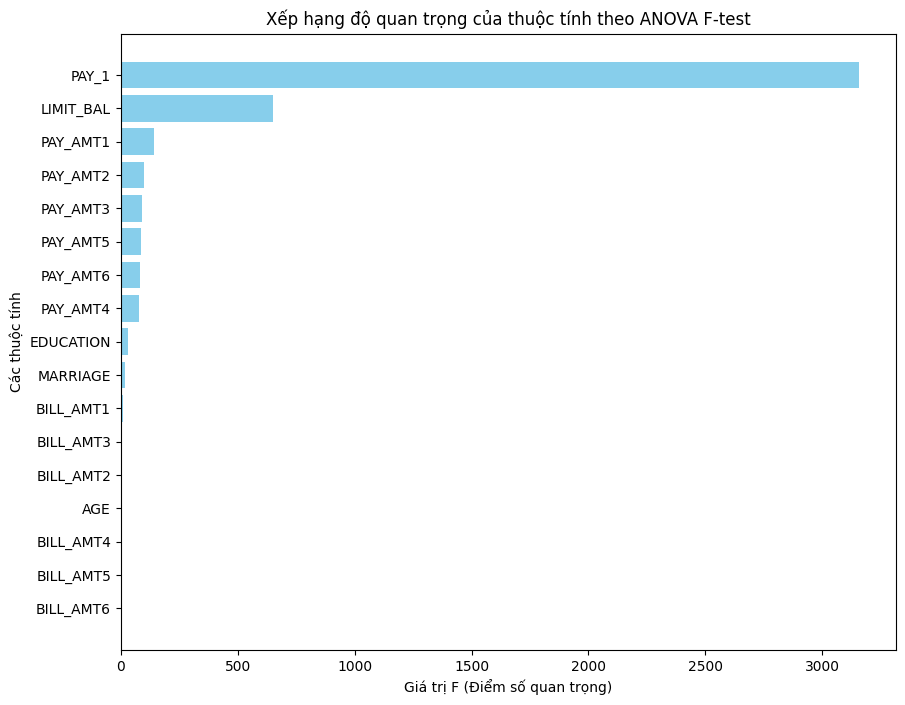

In [12]:
import matplotlib.pyplot as plt

feature_scores = pd.DataFrame({
    'Thuộc tính': attrs_exp,
    'Điểm F': selector_k.scores_
})

feature_scores = feature_scores.sort_values(by='Điểm F', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_scores['Thuộc tính'], feature_scores['Điểm F'], color='skyblue')
plt.xlabel('Giá trị F (Điểm số quan trọng)')
plt.ylabel('Các thuộc tính')
plt.title('Xếp hạng độ quan trọng của thuộc tính theo ANOVA F-test')
plt.gca().invert_yaxis()
plt.show()

Việc sử dụng `SelectKBest` cho phép chúng ta kiểm soát chính xác số lượng đầu vào của mô hình. Trong tập dữ liệu này, 5 biến quan trọng nhất thường tập trung vào trạng thái thanh toán gần nhất `PAY_1` và các biến về hạn mức tín dụng hoặc lịch sử thanh toán gần đây, giúp mô hình tập trung vào các tín hiệu nhiễu thấp nhất.